# Cross-Country Flights: Price Prediction Modeling ✈️
## Notebook 4: Machine Learning Models
### Will Bartlett & Kevin Tran

This notebook performs modeling to predict a flight's price the next day. Imported data has engineered features and is ready for modeling.

In [69]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import time

### 1. Import Data & Train/Test Split

In [70]:
df = pd.read_csv('../data/features_engineered.csv')

In [71]:
# Temporal train-test split; 80% train, 20% test
df['search_date'] = pd.to_datetime(df['search_date'])
split_date = df['search_date'].quantile(0.8)
train = df[df['search_date'] < split_date]
test = df[df['search_date'] >= split_date]

In [72]:
# Prepare feature train & test matricies
X_train = train.drop(['search_date', 'price_tomorrow'], axis=1)
X_test = test.drop(['search_date', 'price_tomorrow'], axis=1)

# Prepare target train & test vectors
y_train = train['price_tomorrow']
y_test = test['price_tomorrow']

# Display sizes
print(f'Training set size: {X_train.shape}, Test set size: {X_test.shape}')

Training set size: (97601, 36), Test set size: (26146, 36)


### 2. Linear Regression

In [73]:
# Scale data for linear regression ONLY (not necessary for tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
# Train linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

### 3. Decision Tree

In [75]:
# Hyperparameter Tuning 
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Grid search with cross-validation
dt = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(
    dt, 
    param_grid_dt, 
    cv=3,  # 3-fold CV]
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

Fitting 3 folds for each of 135 candidates, totalling 405 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 10, 20]},
             scoring='neg_mean_absolute_error', verbose=1)

In [76]:
# Save Best Model
best_dt = grid_dt.best_estimator_

# Predict using Best Model
y_pred_dt = best_dt.predict(X_test)

# Evaluate
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

### 4. Random Forest

In [77]:
# Hyperparameter Tuning - random search for speed
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Random Search
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search_rf = RandomizedSearchCV(
    rf,
    param_dist_rf,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [78]:
# Save Best Model
best_rf = random_search_rf.best_estimator_

# Predict using Best Model
y_pred_rf = best_rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

### 5. XGBoost

In [79]:
# Hyperparameter Tuning - using Random Search
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Random search
xgb = XGBRegressor(random_state=42, n_jobs=-1)
random_search_xgb = RandomizedSearchCV(
    xgb,
    param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [80]:
# Save Best model
best_xgb = random_search_xgb.best_estimator_

# Predict using Best Model
y_pred_xgb = best_xgb.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

### 6. Model Comparisons

In [81]:
print(f"\nLinear Regression Results:")
print(f"  MAE:  ${mae_lr:.2f}")
print(f"  RMSE: ${rmse_lr:.2f}")
print(f"  R²:   {r2_lr:.3f}")

print(f"\nDecision Tree Results:")
print(f"  MAE:  ${mae_dt:.2f}")
print(f"  RMSE: ${rmse_dt:.2f}")
print(f"  R²:   {r2_dt:.3f}")

print(f"\nRandom Forest Results:")
print(f"  MAE:  ${mae_rf:.2f}")
print(f"  RMSE: ${rmse_rf:.2f}")
print(f"  R²:   {r2_rf:.3f}")

print(f"\nXGBoost Results:")
print(f"  MAE:  ${mae_xgb:.2f}")
print(f"  RMSE: ${rmse_xgb:.2f}")
print(f"  R²:   {r2_xgb:.3f}")


Linear Regression Results:
  MAE:  $18.64
  RMSE: $32.52
  R²:   0.991

Decision Tree Results:
  MAE:  $15.44
  RMSE: $38.29
  R²:   0.987

Random Forest Results:
  MAE:  $14.41
  RMSE: $32.23
  R²:   0.991

XGBoost Results:
  MAE:  $15.03
  RMSE: $33.99
  R²:   0.990


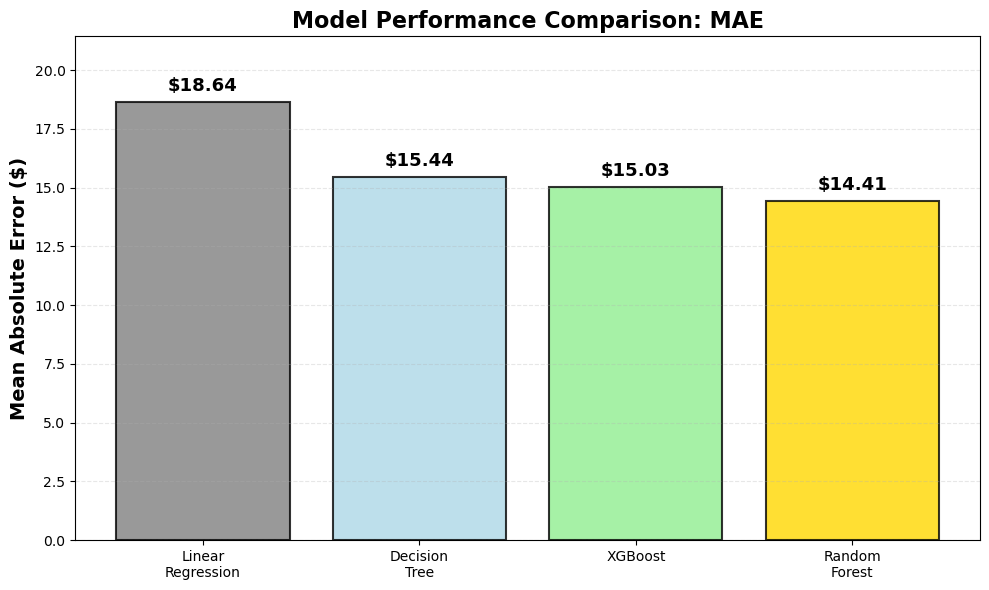

In [82]:
# MAE Comparison Visualization
models = ['Linear\nRegression', 'Decision\nTree', 'XGBoost', 'Random\nForest']
mae_values = [mae_lr, mae_dt, mae_xgb, mae_rf]
colors = ['gray', 'lightblue', 'lightgreen', 'gold']

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
bars = ax.bar(models, mae_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Labels and title
ax.set_ylabel('Mean Absolute Error ($)', fontsize=14, fontweight='bold')
ax.set_title('Model Performance Comparison: MAE', fontsize=16, fontweight='bold')
ax.set_ylim([0, max(mae_values) * 1.15])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, mae_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'${val:.2f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 7. Feature Importance

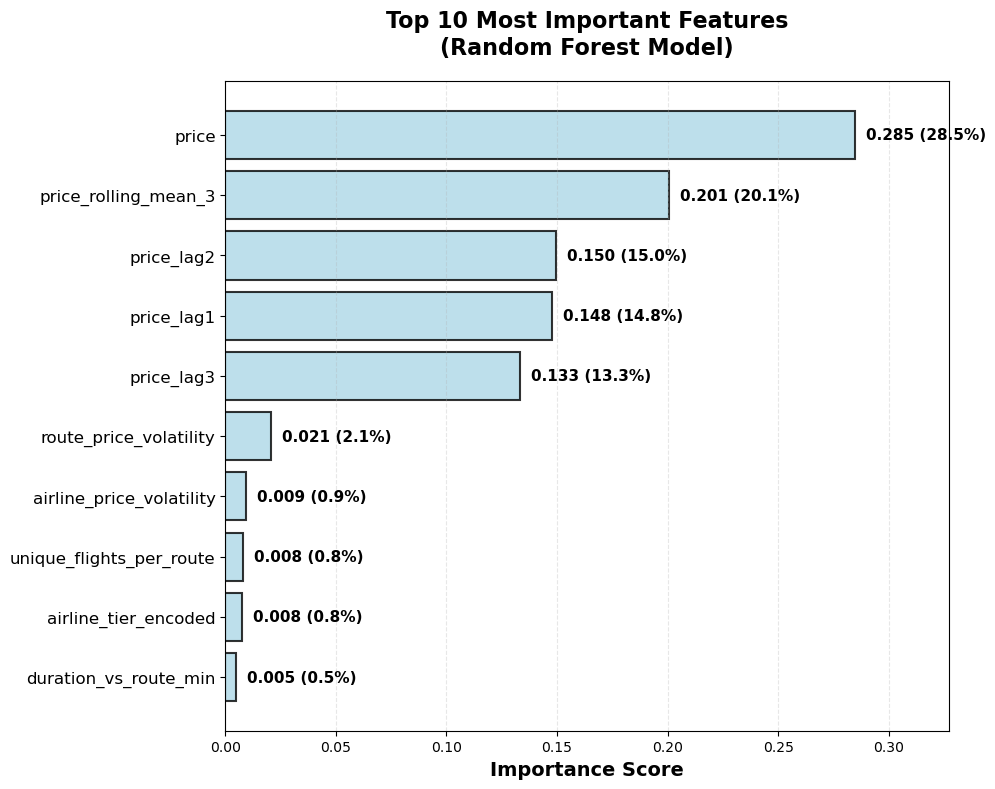

In [83]:
### Feature Importance Visualization 

feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Get top 10 features
top_10_features = feature_importance_rf.head(10).copy()

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart
bars = ax.barh(range(len(top_10_features)), 
               top_10_features['importance'], 
               color='lightblue',
               alpha=0.8,
               edgecolor='black',
               linewidth=1.5)

# Customize
ax.set_yticks(range(len(top_10_features)))
ax.set_yticklabels(top_10_features['feature'], fontsize=12)
ax.invert_yaxis()  # Highest at top
ax.set_xlabel('Importance Score', fontsize=14, fontweight='bold')
ax.set_title('Top 10 Most Important Features\n(Random Forest Model)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim([0, max(top_10_features['importance']) * 1.15])

# Add grid
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_10_features['importance'])):
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f} ({val*100:.1f}%)',
            ha='left', va='center', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()